In [1]:
import os
import gc
import sys
import yaml
import logging
import warnings
from glob import glob
from pathlib import Path
from argparse import ArgumentParser
import multiprocessing as mp
from collections import defaultdict

# ---------- #
# Numerics
from datetime import datetime, timedelta
import xarray as xr
import numpy as np
import pandas as pd

# ---------- #
import torch
from torchvision import transforms as tforms
# ---------- #
# credit
from credit.models import load_model
from credit.seed import seed_everything
from credit.distributed import get_rank_info
from credit.data import (
    subset_patch,
    concat_and_reshape,
    reshape_only,
    get_forward_data,
    drop_var_from_dataset,
    extract_month_day_hour,
    find_common_indices,
    filter_ds,
)

from credit.transforms.transforms_les import Normalize_LES, ToTensor_LES

from credit.pbs import launch_script, launch_script_mpi
from credit.forecast import load_forecasts
from credit.distributed import distributed_model_wrapper, setup
from credit.models.checkpoint import load_model_state
from credit.parser import credit_main_parser, predict_data_check
from credit.output import load_metadata, make_xarray, save_netcdf_clean

logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# ---- cudnn global settings
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True  # good if H,W are fixed

# if PyTorch ≥ 2.0
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

In [2]:
def _to_ns(dt):
    """Normalize datetimes to numpy datetime64[ns] for consistent comparisons."""
    return np.asarray(dt, dtype="datetime64[ns]")

In [3]:
# ======================================================== #
# load config
# -------------------------------------------------------- #
config_name = '/glade/work/ksha/DWC_runs/FE_new/model_single.yml'
# config_name = '/glade/work/ksha/DWC_runs/CONUS_GP_clean/model_clim.yml'
# Read YAML file
with open(config_name, 'r') as stream:
    conf = yaml.safe_load(stream)

conf = credit_main_parser(conf, parse_training=False, parse_predict=True, print_summary=False)

rank = 0
world_size = 1
N_steps = 90 # conf['predict']['forecasts']['pred_step']

In [6]:
for i in range(13):

    conf['predict']['forecasts']['year_range'] = [i, i+1]
    
    # ======================================================== #
    # load pytorch model
    # -------------------------------------------------------- #
    
    # flag for distributed inference
    distributed = False #conf["predict"]["mode"] in ["ddp", "fsdp"]
    
    # # set prediction device
    # # -------------------------------------------------------- #
    # if conf["predict"]["mode"] in ["fsdp", "ddp"]:
    #     setup(rank, world_size, conf["predict"]["mode"])
    
    # infer device id from rank
    if torch.cuda.is_available():
        device_id = rank % torch.cuda.device_count()
        device = torch.device(f"cuda:{device_id}")
        torch.cuda.set_device(device_id)
    else:
        device = torch.device("cpu")
    
    # -------------------------------------------------------- #
    # main loading block
    # if conf["predict"]["mode"] == "none":
    model = load_model(conf, load_weights=True).to(device)
    
    # elif conf["predict"]["mode"] == "ddp":
    #     model = load_model(conf).to(device)
    #     # if conf["trainer"].get("compile", False):
    #     #     model = torch.compile(model)
    #     model = distributed_model_wrapper(conf, model, device)
    #     ckpt = os.path.join(save_loc, "checkpoint.pt")
    #     checkpoint = torch.load(ckpt, map_location=device)
    #     load_msg = model.module.load_state_dict(checkpoint["model_state_dict"], strict=False)
    #     load_state_dict_error_handler(load_msg)
    
    # elif conf["predict"]["mode"] == "fsdp":
    #     model = load_model(conf, load_weights=True).to(device)
    #     model = distributed_model_wrapper(conf, model, device)
    #     # Load model weights (if any), an optimizer, scheduler, and gradient scaler
    #     model = load_model_state(conf, model, device)
    # -------------------------------------------------------- #
    # set to eval
    model.eval()
    
    # ======================================================== #
    # DATA: data normalization process
    # -------------------------------------------------------- #
    state_transformer = Normalize_LES(conf)
    to_tensor_scaler = ToTensor_LES(conf)
    transforms = tforms.Compose([state_transformer, to_tensor_scaler])
    
    # ======================================================== #
    # DATA: load information from conf
    # -------------------------------------------------------- #
    ind_start = conf['predict']['forecasts']['start_ind']
    test_years_range = conf['predict']['forecasts']['year_range']
    
    # random seed
    seed = conf["seed"]
    seed_everything(seed)
    
    # length of forecast steps (e.g., hourly)
    lead_time_periods = conf["data"]["lead_time_periods"]
    
    # number of diagnostic variables (e.g., 0)
    varnum_diag = len(conf["data"]["diagnostic_variables"])
    
    # number of dynamic forcing + forcing + static (e.g., 0)
    static_dim_size = len(conf["data"]["dynamic_forcing_variables"]) + \
                      len(conf["data"]["forcing_variables"]) + \
                      len(conf["data"]["static_variables"])
    
    # bool flag for each variable type
    flag_dyn_forcing = ("dynamic_forcing_variables" in conf["data"]) and (len(conf["data"]["dynamic_forcing_variables"]) > 0)
    flag_forcing = ("forcing_variables" in conf["data"]) and (len(conf["data"]["forcing_variables"]) > 0)
    flag_static = ("static_variables" in conf["data"]) and (len(conf["data"]["static_variables"]) > 0)
    
    # if multiple of static, forcing, dynamic forcing exists, create a bool flag to set their order
    if flag_forcing or flag_static:
        # ======================================================================================== #
        # forcing variable first (new models) vs. static variable first (some old models)
        # this flag makes sure that the class is compatible with some old CREDIT models
        flag_static_first = ("static_first" in conf["data"]) and (conf["data"]["static_first"])
        # ======================================================================================== #
    else:
        has_forcing_static = False
    
    
    # ======================================================== #
    # DATA: select relavant data files based on the year
    # -------------------------------------------------------- #
    # upper air files
    upper_files = sorted(glob(conf["data"]["save_loc"]))
    
    # --------------- #
    # surface files
    if ("surface_variables" in conf["data"]) and (len(conf["data"]["surface_variables"]) > 0):
        list_surf_ds = sorted(glob(conf["data"]["save_loc_surface"]))
    else:
        list_surf_ds = None
    
    # --------------- #
    # dyn forcing files
    if ("dynamic_forcing_variables" in conf["data"]) and (len(conf["data"]["dynamic_forcing_variables"]) > 0):
        list_dyn_forcing_ds = sorted(glob(conf["data"]["save_loc_dynamic_forcing"]))
    else:
        list_dyn_forcing_ds = None
    
    
    # convert year info to str for file name search
    test_years = [str(year) for year in range(test_years_range[0], test_years_range[1])]
    
    # Filter files
    test_files = [file for file in upper_files if any(year in file for year in test_years)]
    test_list_surf_ds = [file for file in list_surf_ds if any(year in file for year in test_years)] if list_surf_ds is not None else None
    test_list_dyn_forcing_ds = [file for file in list_dyn_forcing_ds if any(year in file for year in test_years)] if list_dyn_forcing_ds is not None else None
    
    # -------------------------------------------------------- #
    # summarize selected file name info
    filenames = test_files
    filename_surface = test_list_surf_ds
    filename_dyn_forcing = test_list_dyn_forcing_ds
    
    
    # ======================================================== #
    # DATA: open all data as xr.datasets
    # -------------------------------------------------------- #
    # varname info: major domain
    varname_upper_air = conf["data"]["variables"]
    varname_surface = conf["data"]["surface_variables"]
    varname_dyn_forcing = conf["data"]["dynamic_forcing_variables"]
    varname_forcing = conf["data"]["forcing_variables"]
    varname_static = conf["data"]["static_variables"]
    filename_forcing = conf["data"]["save_loc_forcing"]
    filename_static = conf["data"]["save_loc_static"]
    
    # time info
    history_len = conf["data"]["history_len"]
    assert history_len == 1, 'only conf["data"]["history_len"] = 1 is supported for this application'
    
    # -------------------------------------------------------- #
    # open data: major domain
    ds_domain = get_forward_data(conf["loss"]["latitude_weights"])
    meta_data = load_metadata(conf)
    
    list_upper_ds = []
    list_surf_ds = []
    list_dyn_forcing_ds = []
    
    # upper‐air
    initial_ds = filter_ds(get_forward_data(filenames[0]), varname_upper_air).isel(time=slice(ind_start, ind_start+history_len))
    
    # surface
    if filename_surface:
        surf_ds = filter_ds(get_forward_data(filename_surface[0]), varname_surface).isel(time=slice(ind_start, ind_start+history_len))
        initial_ds = xr.merge([initial_ds, surf_ds])
    else:
        surf_ds = False
    
    # dynamic forcing
    if filename_dyn_forcing:
        list_dyn_forcing_ds = [filter_ds(ds, varname_dyn_forcing) for ds in all_ds]
        # concat multi-year ds to one
        dyn_forcing_ds = xr.concat(list_dyn_forcing_ds, dim='time')
        # also merge the first ds to initial_ds
        initial_ds = xr.merge([initial_ds, list_dyn_forcing_ds[0]])
    else:
        list_dyn_forcing_ds = False
    
    # forcing
    if filename_forcing is not None:
        # drop variables if they are not in the config
        ds = get_forward_data(filename_forcing)
        xarray_forcing = drop_var_from_dataset(ds, varname_forcing).load()
    else:
        xarray_forcing = False
    
    # static
    if filename_static is not None:
        # drop variables if they are not in the config
        ds = get_forward_data(filename_static)
        xarray_static = drop_var_from_dataset(ds, varname_static).load()
        xarray_static = xarray_static.expand_dims(dim={"time": len(initial_ds["time"])})
    else:
        xarray_static = False
    
    # ======================================================== #
    # DATA: summarize other relavent conf info
    # -------------------------------------------------------- #
    lead_time_unit = conf['data']['lead_time_unit']
    
    initial_time = initial_ds['time'].values[0]
    
    fcst_timesteps = np.arange(
        initial_time, 
        initial_time + (N_steps+1)*np.timedelta64(lead_time_periods, lead_time_unit), 
        np.timedelta64(lead_time_periods, lead_time_unit)
    )
    
    init_datetime = datetime.utcfromtimestamp(initial_time.astype("datetime64[s]").astype(int))
    
    init_datetime_str = init_datetime.strftime("%Y-%m-%dT%HZ")
    
    
    # ======================================================== #
    # prediction section
    # -------------------------------------------------------- #
    for i_step in range(1, 1+N_steps, 1):
        print(f'pred step = {i_step}')
        results = []
        
        # -------------------------------------------------------- #
        # add forcing & static to initial conditions 
        
        # static field
        if filename_static is not None:
            
            xarray_static["time"] = initial_ds["time"]
            initial_ds = xr.merge([initial_ds, xarray_static])
        
        # forcing field gen
        if filename_forcing is not None:
            month_day_forcing = extract_month_day_hour(np.array(xarray_forcing["time"]))
            month_day_inputs = extract_month_day_hour(np.array(fcst_timesteps[i_step-1]))
            # indices to subset
            ind_forcing, _ = find_common_indices(month_day_forcing, month_day_inputs)
            xarray_forcing = xarray_forcing.isel(time=ind_forcing)
            # forcing field
            xarray_forcing["time"] = initial_ds["time"]
            initial_ds = initial_ds.merge(xarray_forcing)
    
        
        initial_ds = subset_patch(initial_ds, input_size=(256, 256), start=None)
        # -------------------------------------------------------- #
        # main prediction loop
        # -------------------------------------------------------- #
        # the first prediction step, use initialization directly
        if i_step == 1:
            x = initial_ds
            
            sample_x = {
                "LES_input": x,
            }
            
            batch = batch_initial = transforms(sample_x)
            
            if "x_surf" in batch:
                # combine x and x_surf
                # input: (batch_num, time, var, level, lat, lon), (batch_num, time, var, lat, lon)
                # output: (batch_num, var, time, lat, lon), 'x' first and then 'x_surf'
                x_surf = batch["x_surf"][None, ...]
            else:
                # no x_surf
                x_surf = None
    
            x = (
                concat_and_reshape(batch["x"][None, ...], x_surf).to(device)
                if x_surf is not None
                else reshape_only(batch["x"][None, ...]).to(device)
            )
    
            # add forcing and static variables (regardless of fcst hours)
            if "x_forcing_static" in batch:
                # (batch_num, time, var, lat, lon) --> (batch_num, var, time, lat, lon)
                x_forcing_batch = batch["x_forcing_static"][None, ...].to(device).permute(0, 2, 1, 3, 4)
                
                # concat on var dimension
                x = torch.cat((x, x_forcing_batch), dim=1)
                
        # -------------------------------------------------------- #
        # rolling steps, use the previous output as input
        else:
            # not the first step, y_pred exist
            # y_pred = state_transformer.transform_array(y_pred) #.to(device)
            
            # ============================================================ #
            # prepare x
            # ------------------------------------------------------------ #
            # use previous step y_pred as the next step x
            if history_len == 1:
                # cut diagnostic vars from y_pred, they are not inputs
                if "y_diag" in batch:
                    x = y_pred[:, :-varnum_diag, ...].detach()
                else:
                    x = y_pred.detach()
                # TO DO: concat dynamic forcing
            
            # multi-step in
            else:
                if static_dim_size == 0:
                    x_detach = x[:, :, 1:, ...].detach()
                else:
                    x_detach = x[:, :-static_dim_size, 1:, ...].detach()
        
                # cut diagnostic vars from y_pred, they are not inputs
                if "y_diag" in batch:
                    x = torch.cat([x_detach, y_pred[:, :-varnum_diag, ...].detach()], dim=2)
                else:
                    x = torch.cat([x_detach, y_pred.detach()], dim=2)
                    
            # ------------------------------------------------------------ #
            # add static, forcing, dynamic forcing, if any, to x
            
            forcing_static_tensor = None
            
            # if static only, pull static tensor from the initial condition 
            if flag_static and not flag_forcing and not flag_dyn_forcing:
                if "x_forcing_static" in batch_initial:
                    # (batch_num, time, var, lat, lon) --> (batch_num, var, time, lat, lon)
                    forcing_static_tensor = batch_initial["x_forcing_static"]
                    
                    # concat on var dimension
                    
            # a more general solution if forcing or dynmaic forcing are invloved
            elif flag_static or flag_forcing or flag_dyn_forcing:
    
                # define rolling_ds to host static, forcing, dynamic forcing
                rolling_ds = xr.Dataset(coords={"time": ("time", np.array([fcst_timesteps[i_step-1],]))})
    
                # ------------------------------------------------------ #
                # merge static and forcing to rolling_ds
                if flag_static:
                    xarray_static["time"] = rolling_ds['time']
                    rolling_ds = xr.merge([rolling_ds, xarray_static])
                    
                if flag_forcing:
                    xarray_forcing = rolling_ds['time']
                    rolling_ds = xr.merge([rolling_ds, xarray_forcing])
    
                if flag_dyn_forcing:
                    dyn_forcing_subset = dyn_forcing_ds.isel(time=slice(i_step-1, i_step))
                    rolling_ds = xr.merge([rolling_ds, dyn_forcing_subset])
    
                # ------------------------------------------------------ #
                # xarray --> np.array --> tensor
                if flag_static_first:
                    varname_forcing_static = varname_static + varname_dyn_forcing + varname_forcing
                else:
                    varname_forcing_static = varname_dyn_forcing + varname_forcing + varname_static
    
                list_vars_forcing_static = []
                for var_name in varname_forcing_static:
                    var_value = rolling_ds[var_name].values
                    list_vars_forcing_static.append(var_value)
                numpy_vars_forcing_static = np.array(list_vars_forcing_static)
                
                x_static = torch.as_tensor(numpy_vars_forcing_static).squeeze()
    
                if len(x_static.shape) == 4:
                    # permute: [forcing_var, time, lat, lon] --> [time, forcing_var, lat, lon]
                    x_static = x_static.permute(1, 0, 2, 3)
    
                elif len(x_static.shape) == 3:
                    if num_forcing_static > 1:
                        # single time, multi-vars
                        x_static = x_static.unsqueeze(0)
                    else:
                        # multi-time, single vars
                        x_static = x_static.unsqueeze(1)
                else:
                    # num_var=1, time=1, only has lat, lon
                    x_static = x_static.unsqueeze(0).unsqueeze(0)
                    # x_static = x_static.unsqueeze(1)
    
                # ------------------------------------------------------ #
                # concat to x
                forcing_static_tensor = x_static
    
            if forcing_static_tensor is not None:
                x = torch.cat((x, forcing_static_tensor[None, ...].to(device).permute(0, 2, 1, 3, 4)), dim=1)
                
        # # -------------------------------------------------------------------------------------- #
        # # start prediction
        y_pred = model(x)
        
        print('============================')
        print((float(x.min()), float(x.max())))
        print((float(y_pred.min()), float(y_pred.max())))
        
        y_pred_save = state_transformer.inverse_transform(y_pred.cpu()).detach()
        
        utc_datetime = init_datetime + timedelta(hours=lead_time_periods * i_step)
        
        # convert the current step result as x-array
        darray_upper_air = make_xarray(
            y_pred_save,
            utc_datetime,
            ds_domain["yIndex"].values[319:575],
            ds_domain["xIndex"].values[320:576],
            conf,
        )
    
        # Save the current forecast hour data in parallel
        # result = p.apply_async(
        #     save_netcdf_clean,
        #     (
        #         darray_upper_air,
        #         None,
        #         init_datetime_str,
        #         i_step,
        #         meta_data,
        #         conf,
        #     ),
        # )
        save_netcdf_clean(
            darray_upper_air,
            None,
            init_datetime_str,
            i_step, # lead_time_periods * i_step
            meta_data,
            conf,
        )
    
        #results.append(result)
    
        # release GPU memory
        torch.cuda.empty_cache()
        gc.collect()
    
        if i_step == N_steps:
            # Wait for all processes to finish in order
            for result in results:
                result.get()
                
            # # forecast count = a constant for each run
            # forecast_count += 1
    
            # # y_pred allocation
            # y_pred = None
    
            gc.collect()
    
            if distributed:
                torch.distributed.barrier()
    
    if distributed:
        torch.distributed.barrier()

conf['predict']['metadata'] not given. Skip.
pred step = 1
(-10.167946815490723, 12.478693008422852)
(-10.131379127502441, 12.423957824707031)
pred step = 2


OutOfMemoryError: CUDA out of memory. Tried to allocate 24.00 MiB. GPU 0 has a total capacity of 31.73 GiB of which 11.69 MiB is free. Including non-PyTorch memory, this process has 31.71 GiB memory in use. Of the allocated memory 31.14 GiB is allocated by PyTorch, and 150.50 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Check result

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

In [25]:
ds = xr.open_dataset('/glade/derecho/scratch/ksha/DWC/RAW_OUTPUT/FE_new/2018-01-01T12Z/pred_2018-01-01T12Z_030.nc')
data = ds['theta'].isel(level=0).values

In [20]:
ds = xr.open_zarr('/glade/derecho/scratch/ksha/FastEddy/FE_04lev/experiment_00.zarr')
ds = subset_patch(ds, input_size=(256, 256), start=None)
target = ds['theta'].isel(zIndex=0).values

In [23]:
vmin, vmax = np.min(target), np.max(target)

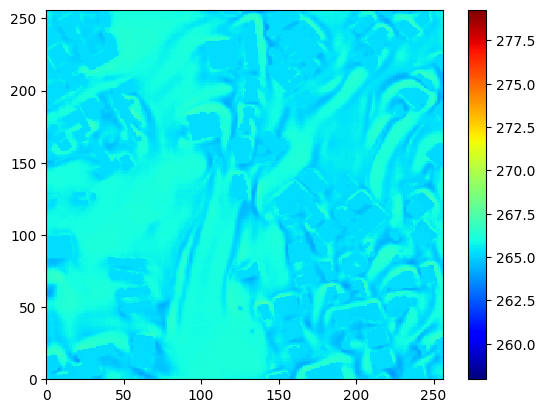

In [24]:
plt.pcolormesh(data[0, ...], vmin=vmin, vmax=vmax, cmap=plt.cm.jet)
plt.colorbar()

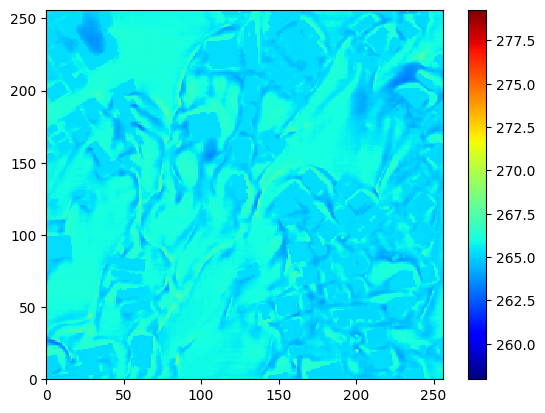

In [26]:
plt.pcolormesh(data[0, ...], vmin=vmin, vmax=vmax, cmap=plt.cm.jet)
plt.colorbar()

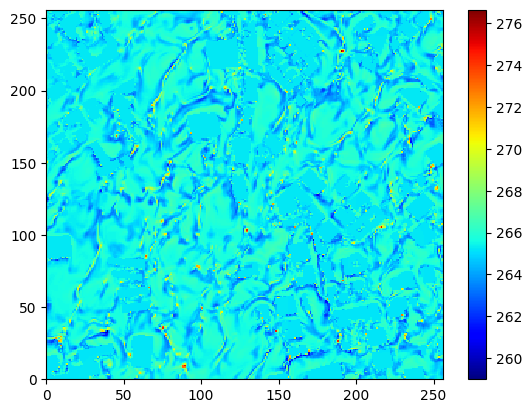

In [18]:
plt.pcolormesh(target[3, ...], cmap=plt.cm.jet)
plt.colorbar()